# Primer parcial
Dataset que consiste en datos simulados sobre la calidad del agua y cómo esta afecta al rendimiento de los filtros de agua, se cuenta con alrededor de 43000 datos, el tiempo esta medido en por cada hora, osea que al final se convertira los dias a horas para poder hacer la prediccion

In [49]:
import pandas as pd
import torch
import numpy as np

con datos en string en una columna cosa que perjudica, esto lo solucionamos dandole valores enteros

NE = 0, NW = 1, SE = 2, cv = 3

Otro punto importante es que el dato de date no se lo interpreta bien, por lo que se separara cada dato a diferentes columnas para tomarlas en cuenta, seran separadas en 

In [68]:
data = pd.read_csv('Multivariate_pollution.csv', delimiter=',')
data["date"] = pd.to_datetime(data["date"])

# Día de la semana (0=lunes, 6=domingo)
data["dayofweek"] = data["date"].dt.dayofweek  

# Fin de semana o no
data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)

# Hora del día
data["hour"] = data["date"].dt.hour  

# Mes del año
data["month"] = data["date"].dt.month  
mapping = {
    "NE": 0,
    "NW": 1,
    "SE": 2,
    "cv": 3
}
data["wnd_dir"] = data["wnd_dir"].map(mapping)
print(data.head())


                 date  pollution  dew  temp   press  wnd_dir  wnd_spd  snow  \
0 2010-01-02 00:00:00      129.0  -16  -4.0  1020.0        2     1.79     0   
1 2010-01-02 01:00:00      148.0  -15  -4.0  1020.0        2     2.68     0   
2 2010-01-02 02:00:00      159.0  -11  -5.0  1021.0        2     3.57     0   
3 2010-01-02 03:00:00      181.0   -7  -5.0  1022.0        2     5.36     1   
4 2010-01-02 04:00:00      138.0   -7  -5.0  1022.0        2     6.25     2   

   rain  dayofweek  is_weekend  hour  month  
0     0          5           1     0      1  
1     0          5           1     1      1  
2     0          5           1     2      1  
3     0          5           1     3      1  
4     0          5           1     4      1  


Mostramos los datos ya en su respectiva variable para ver si todo salio bien

In [55]:
X = data.drop(["pollution", "date"], axis=1)
y = data["pollution"]   
X, y              

(       dew  temp   press  wnd_dir  wnd_spd  snow  rain  dayofweek  is_weekend  \
 0      -16  -4.0  1020.0        2     1.79     0     0          5           1   
 1      -15  -4.0  1020.0        2     2.68     0     0          5           1   
 2      -11  -5.0  1021.0        2     3.57     0     0          5           1   
 3       -7  -5.0  1022.0        2     5.36     1     0          5           1   
 4       -7  -5.0  1022.0        2     6.25     2     0          5           1   
 ...    ...   ...     ...      ...      ...   ...   ...        ...         ...   
 43795  -23  -2.0  1034.0        1   231.97     0     0          2           0   
 43796  -22  -3.0  1034.0        1   237.78     0     0          2           0   
 43797  -22  -3.0  1034.0        1   242.70     0     0          2           0   
 43798  -22  -4.0  1034.0        1   246.72     0     0          2           0   
 43799  -21  -3.0  1034.0        1   249.85     0     0          2           0   
 
        hour  

El dataset cuenta con 43801 datos lo cual ahora nos da marjen para poder hacer o siguiente y dividir los datos

train = 75%

test = 15%

val = 10%


In [56]:
from sklearn.model_selection import train_test_split

# 5% de los datos se separa para validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.05, random_state=42)

# Tomar un 10% del total (aprox.) como subset de entrenamiento
X_subset, _, y_subset, _ = train_test_split(X_train, y_train, test_size=0.9, random_state=42)

# --- Agregando test set (15% del total) ---
X_temp = X.drop(X_train.index, axis=0)  # lo que no está en train
y_temp = y.drop(y_train.index, axis=0)

X_test, _, y_test, _ = train_test_split(X_temp, y_temp, test_size=0.3333, random_state=42)

X_train, y_train.shape, X_val.shape, y_val.shape, X_subset.shape, y_subset.shape, X_test.shape, y_test.shape
# 0.3333 ≈ 1/3 del 25% restante → 15% del total


(       dew  temp   press  wnd_dir  wnd_spd  snow  rain  dayofweek  is_weekend  \
 30113   16  18.0  1011.0        1    53.64     0    10          6           1   
 36366   -5  -2.0  1027.0        1     3.57     0     0          1           0   
 12551   19  24.0  1002.0        2    34.86     0     0          2           0   
 39116   18  24.0  1005.0        2    47.37     0     0          3           0   
 29473   13  16.0  1005.0        3     0.89     0     0          1           0   
 ...    ...   ...     ...      ...      ...   ...   ...        ...         ...   
 6265    15  17.0  1011.0        2     4.47     0     0          0           0   
 11284   -4  17.0  1007.0        1    18.77     0     0          6           1   
 38158    3  17.0  1016.0        2    14.75     0     1          5           1   
 860     -7  -4.0  1029.0        2    37.10     2     0          5           1   
 15795    9  10.0  1018.0        1     0.89     0     0          5           1   
 
        hour  

Normalizaremos en este caso x y de forma separada, aqui normalizamos y primero

In [59]:
y_min = y_train.min()
y_max = y_train.max()

y_train = (y_train - y_min) / (y_max - y_min)
y_val   = (y_val - y_min) / (y_max - y_min)

Para x como cada columna tiene rangos distintos para poder normlaizar con un solo valor seria tener multiples errores, ahora lo que se hara sera que para cada columna sera una normalizacion individual asi todos los valores rondan entre 0 y 1

In [60]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        # Convertir a np.ndarray si es DataFrame/Series
        X = X.values if hasattr(X, "values") else X
        Y = Y.values if hasattr(Y, "values") else Y
        
        # Normalización columna por columna (Min-Max)
        X_min = X.min(axis=0)        # mínimo de cada columna
        X_max = X.max(axis=0)        # máximo de cada columna
        X_norm = (X - X_min) / (X_max - X_min + 1e-8)  # evitar división por 0
        
        # Convertir a tensores
        self.X = torch.from_numpy(X_norm).float().cuda()
        self.Y = torch.from_numpy(Y).float().cuda()  # float para regresión
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

dataset = {
    'train': Dataset(X_train, y_train),
    'val': Dataset(X_val, y_val),
}
dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

len(dataset['train']), len(dataset['val'])
# Convertir el tensor normalizado a NumPy para verlo
X_train_norm = dataset['train'].X.cpu().numpy()  # si estás usando GPU, .cpu() lo trae a RAM
y_train_norm = dataset['train'].Y.cpu().numpy()

print("X normalizado (train):")
print(X_train_norm)

print("y (train):")
print(y_train_norm)

X normalizado (train):
[[0.8235294  0.60655737 0.36363637 ... 1.         0.73913044 0.45454547]
 [0.5147059  0.27868852 0.6545454  ... 0.         0.26086956 0.09090909]
 [0.86764705 0.704918   0.2        ... 0.         1.         0.45454547]
 ...
 [0.63235295 0.59016395 0.45454547 ... 1.         0.95652175 0.36363637]
 [0.4852941  0.24590164 0.6909091  ... 1.         0.8695652  0.09090909]
 [0.7205882  0.47540984 0.4909091  ... 1.         0.13043478 0.8181818 ]]
y (train):
[0.01207243 0.46579477 0.0472837  ... 0.04024145 0.19014084 0.26257545]


In [ ]:
    from sklearn.metrics import accuracy_score

    def softmax(x):
        return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

    def build_model(D_in=11, H=100, D_out=1):
        return torch.nn.Sequential(
            torch.nn.Linear(D_in, H),
            torch.nn.ReLU(),
            torch.nn.Linear(H, H),
            torch.nn.ReLU(),
            torch.nn.Linear(H, D_out)
        ).cuda()


    def fit_regression(model, dataloader, optimizer, epochs=50, log_each=10, early_stopping=0):
        criterion = torch.nn.MSELoss()  # Pérdida para regresión
        train_l, val_l = [], []
        best_val_loss = float('inf')
        step = 0

        for e in range(1, epochs+1):
            # --- Entrenamiento ---
            model.train()
            _l = []
            for x_b, y_b in dataloader['train']:
                optimizer.zero_grad()
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                loss.backward()
                optimizer.step()
                _l.append(loss.item())
            train_l.append(np.mean(_l))

            # --- Validación ---
            model.eval()
            _l_val = []
            with torch.no_grad():
                for x_b, y_b in dataloader['val']:
                    y_pred = model(x_b)
                    loss = criterion(y_pred, y_b)
                    _l_val.append(loss.item())
            val_loss_epoch = np.mean(_l_val)
            val_l.append(val_loss_epoch)

            # Guardar mejor modelo
            if val_loss_epoch < best_val_loss:
                best_val_loss = val_loss_epoch
                torch.save(model.state_dict(), 'ckpt.pt')
                step = 0
                print(f"Mejor modelo guardado con val_loss {best_val_loss:.5f} en epoch {e}")
            step += 1

            # Early stopping
            if early_stopping and step > early_stopping:
                print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
                break

            # Log
            if not e % log_each:
                print(f"Epoch {e}/{epochs} train_loss {train_l[-1]:.5f} val_loss {val_l[-1]:.5f}")

        # Cargar mejor modelo
        model.load_state_dict(torch.load('ckpt.pt'))
        return {'epoch': list(range(1, len(train_l)+1)), 'train_loss': train_l, 'val_loss': val_l}


Usaremos los optimizadores y veremos como fue aprendiendo el modelo pero esto sera para saber cual modelo es el mas optimo para hacer el test y la prediccion para los 30 dias

# Optimizadores

1. Descenso de Gradiente Estocástico (SGD)

In [64]:
import numpy as np

model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
hist_sgd = fit_regression(model, dataloader, optimizer)

Mejor modelo guardado con val_loss 0.00866 en epoch 1
Mejor modelo guardado con val_loss 0.00866 en epoch 2
Mejor modelo guardado con val_loss 0.00866 en epoch 2
Mejor modelo guardado con val_loss 0.00863 en epoch 3
Mejor modelo guardado con val_loss 0.00863 en epoch 3
Mejor modelo guardado con val_loss 0.00863 en epoch 4
Mejor modelo guardado con val_loss 0.00863 en epoch 4
Mejor modelo guardado con val_loss 0.00863 en epoch 5
Mejor modelo guardado con val_loss 0.00863 en epoch 5
Mejor modelo guardado con val_loss 0.00863 en epoch 6
Mejor modelo guardado con val_loss 0.00863 en epoch 6
Mejor modelo guardado con val_loss 0.00862 en epoch 8
Mejor modelo guardado con val_loss 0.00862 en epoch 8
Mejor modelo guardado con val_loss 0.00861 en epoch 10
Epoch 10/50 train_loss 0.00865 val_loss 0.00861
Mejor modelo guardado con val_loss 0.00861 en epoch 10
Epoch 10/50 train_loss 0.00865 val_loss 0.00861
Mejor modelo guardado con val_loss 0.00861 en epoch 11
Mejor modelo guardado con val_loss 0.

2. Momentum

In [65]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_momentum = fit_regression(model, dataloader, optimizer)

Mejor modelo guardado con val_loss 0.00864 en epoch 1
Mejor modelo guardado con val_loss 0.00862 en epoch 2
Mejor modelo guardado con val_loss 0.00862 en epoch 2
Mejor modelo guardado con val_loss 0.00860 en epoch 3
Mejor modelo guardado con val_loss 0.00860 en epoch 3
Mejor modelo guardado con val_loss 0.00859 en epoch 6
Mejor modelo guardado con val_loss 0.00859 en epoch 6
Mejor modelo guardado con val_loss 0.00858 en epoch 8
Mejor modelo guardado con val_loss 0.00858 en epoch 8
Mejor modelo guardado con val_loss 0.00858 en epoch 10
Epoch 10/50 train_loss 0.00863 val_loss 0.00858
Mejor modelo guardado con val_loss 0.00858 en epoch 10
Epoch 10/50 train_loss 0.00863 val_loss 0.00858
Mejor modelo guardado con val_loss 0.00858 en epoch 13
Mejor modelo guardado con val_loss 0.00858 en epoch 13
Epoch 20/50 train_loss 0.00863 val_loss 0.00859
Epoch 20/50 train_loss 0.00863 val_loss 0.00859
Mejor modelo guardado con val_loss 0.00858 en epoch 22
Mejor modelo guardado con val_loss 0.00858 en e

3. RMS-prop

In [66]:
model = build_model()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
hist_rms = fit_regression(model, dataloader, optimizer)

Mejor modelo guardado con val_loss 0.00869 en epoch 1
Mejor modelo guardado con val_loss 0.00861 en epoch 2
Mejor modelo guardado con val_loss 0.00861 en epoch 2
Mejor modelo guardado con val_loss 0.00856 en epoch 3
Mejor modelo guardado con val_loss 0.00856 en epoch 3
Mejor modelo guardado con val_loss 0.00856 en epoch 6
Mejor modelo guardado con val_loss 0.00856 en epoch 6
Epoch 10/50 train_loss 0.00862 val_loss 0.00860
Epoch 10/50 train_loss 0.00862 val_loss 0.00860
Mejor modelo guardado con val_loss 0.00856 en epoch 13
Mejor modelo guardado con val_loss 0.00856 en epoch 13
Epoch 20/50 train_loss 0.00861 val_loss 0.00856
Epoch 20/50 train_loss 0.00861 val_loss 0.00856
Mejor modelo guardado con val_loss 0.00856 en epoch 26
Mejor modelo guardado con val_loss 0.00856 en epoch 26
Epoch 30/50 train_loss 0.00861 val_loss 0.00859
Epoch 30/50 train_loss 0.00861 val_loss 0.00859
Epoch 40/50 train_loss 0.00862 val_loss 0.00857
Epoch 40/50 train_loss 0.00862 val_loss 0.00857
Epoch 50/50 train_

4. Adam

In [67]:
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
hist_adam = fit_regression(model, dataloader, optimizer)

Mejor modelo guardado con val_loss 0.00857 en epoch 1
Mejor modelo guardado con val_loss 0.00856 en epoch 3
Mejor modelo guardado con val_loss 0.00856 en epoch 3
Mejor modelo guardado con val_loss 0.00856 en epoch 4
Mejor modelo guardado con val_loss 0.00856 en epoch 4
Epoch 10/50 train_loss 0.00863 val_loss 0.00858
Epoch 10/50 train_loss 0.00863 val_loss 0.00858
Mejor modelo guardado con val_loss 0.00856 en epoch 13
Mejor modelo guardado con val_loss 0.00856 en epoch 13
Epoch 20/50 train_loss 0.00862 val_loss 0.00860
Epoch 20/50 train_loss 0.00862 val_loss 0.00860
Epoch 30/50 train_loss 0.00862 val_loss 0.00857
Epoch 30/50 train_loss 0.00862 val_loss 0.00857
Epoch 40/50 train_loss 0.00862 val_loss 0.00858
Epoch 40/50 train_loss 0.00862 val_loss 0.00858
Epoch 50/50 train_loss 0.00862 val_loss 0.00857
Epoch 50/50 train_loss 0.00862 val_loss 0.00857


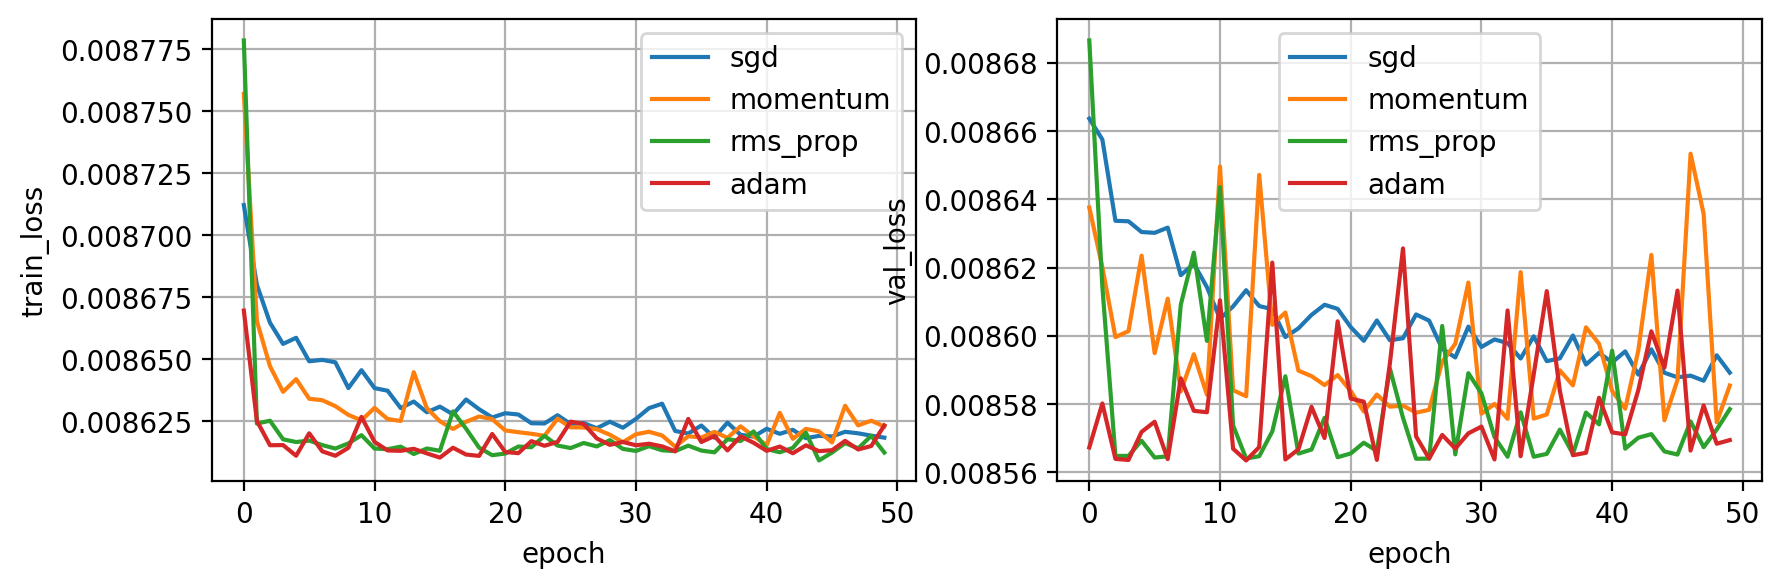

In [71]:
import matplotlib.pyplot as plt

fig = plt.figure(dpi=200, figsize=(10,3))

# Train Loss
ax = plt.subplot(121)
ax.plot(hist_sgd['train_loss'], label="sgd")
ax.plot(hist_momentum['train_loss'], label="momentum")
ax.plot(hist_rms['train_loss'], label="rms_prop")
ax.plot(hist_adam['train_loss'], label="adam")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('train_loss')

# Validation Loss
ax = plt.subplot(122)
ax.plot(hist_sgd['val_loss'], label="sgd")
ax.plot(hist_momentum['val_loss'], label="momentum")
ax.plot(hist_rms['val_loss'], label="rms_prop")
ax.plot(hist_adam['val_loss'], label="adam")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('val_loss')

plt.show()


Interpretación de los 4 resultados

Las pérdidas son muy bajas desde el inicio, lo que indica que el modelo ya está aprendiendo bastante bien los datos.

Hay muy poca diferencia entre train_loss y val_loss, lo cual es bueno: significa que no hay sobreajuste (overfitting).

La pérdida se mantiene estable a lo largo de las 50 épocas, mostrando que el aprendizaje converge rápidamente.

# Prueba con test

In [ ]:
# Normalización de y
y_min = y_train.min()
y_max = y_train.max()

y_test_norm  = (y_test - y_min) / (y_max - y_min)


In [78]:
class DatasetTest(torch.utils.data.Dataset):
    def __init__(self, X, Y, X_min, X_max):
        # Convertir a np.ndarray si es DataFrame/Series
        X = X.values if hasattr(X, "values") else X
        Y = Y.values if hasattr(Y, "values") else Y
        
        # Normalización usando broadcasting
        X_norm = (X - X_min) / (X_max - X_min + 1e-8)
        
        # Convertir a tensores
        self.X = torch.from_numpy(X_norm).float().cuda()
        self.Y = torch.from_numpy(Y).float().cuda()
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

# Normalizar min-max usando arrays numpy
X_min = X_train.min(axis=0).values if hasattr(X_train.min(axis=0), "values") else X_train.min(axis=0)
X_max = X_train.max(axis=0).values if hasattr(X_train.max(axis=0), "values") else X_train.max(axis=0)

dataset_test = DatasetTest(X_test, y_test, X_min, X_max)
dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=32, shuffle=False)


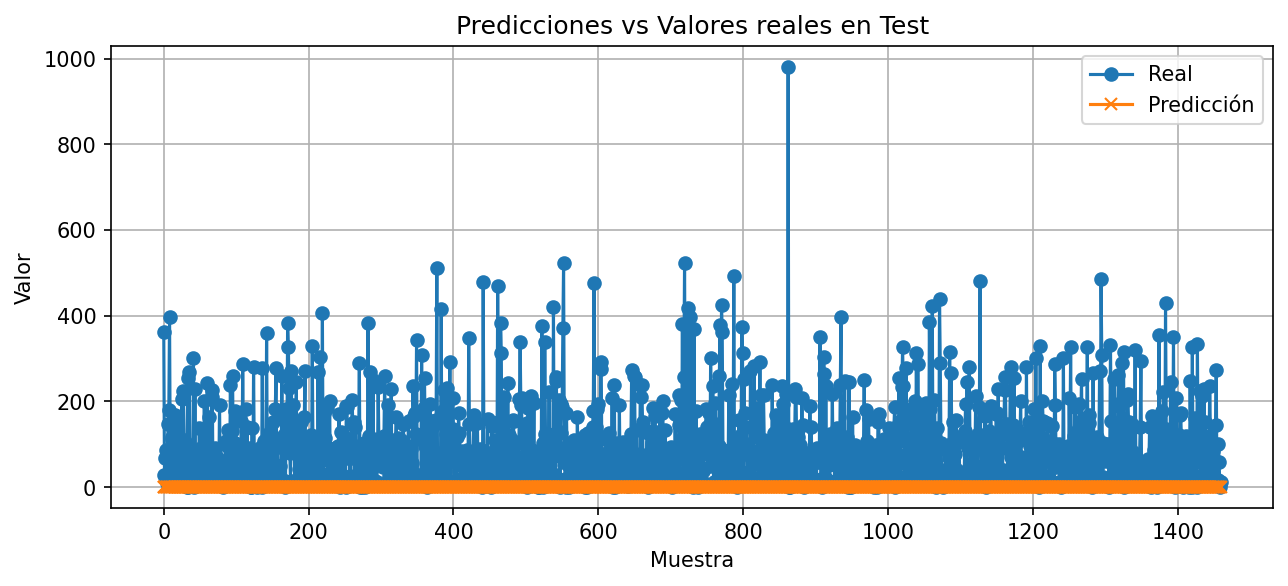

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Cargar modelo y pesos
model = build_model()                    # misma arquitectura usada antes
model.load_state_dict(torch.load("ckpt.pt"))  # cargar pesos del mejor modelo
model.eval()
model.cuda()

# Preparar containers para predicciones y valores reales
preds = []
targets = []

# Evaluación sobre test set
with torch.no_grad():
    for x_b, y_b in dataloader_test:
        y_pred = model(x_b)
        preds.append(y_pred.cpu().numpy())
        targets.append(y_b.cpu().numpy())

# Concatenar batches
preds = np.concatenate(preds).squeeze()
targets = np.concatenate(targets).squeeze()

# desnormalizar los valores para compararlos con la escala original
y_test_denorm = targets * (y_max - y_min) + y_min
preds_denorm = preds * (y_max - y_min) + y_min

# Graficar predicciones vs valores reales
plt.figure(figsize=(10,4), dpi=150)
plt.plot(targets, label="Real", marker='o')
plt.plot(preds, label="Predicción", marker='x')
plt.xlabel("Muestra")
plt.ylabel("Valor")
plt.title("Predicciones vs Valores reales en Test")
plt.legend()
plt.grid(True)
plt.show()



Como podemos obserbar ahora, se ve que tenemos una recta en vz de una inclinada, esto puede deberse a que a pesar que vemos valores variados, la gran mayoria tienen una variacion minima y por este motivo parece una recta, ya que en el entrenamiento se observaron resultados bastante satisfactorios

# Prediccion para 30 dias

In [84]:
model_sgd = build_model()
model_sgd.load_state_dict(torch.load('ckpt.pt'))  # si guardaste con nombre diferente por optimizador
model_sgd.eval().cuda()


Sequential(
  (0): Linear(in_features=11, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=100, bias=True)
  (3): ReLU()
  (4): Linear(in_features=100, out_features=1, bias=True)
)

In [85]:
# Últimos D_in valores del dataset de test
last_window = X_test[-11:].values  # D_in = 11
last_window_norm = (last_window - X_min) / (X_max - X_min + 1e-8)
window = torch.from_numpy(last_window_norm).float().unsqueeze(0).cuda()


In [87]:
preds = []

with torch.no_grad():
    for _ in range(720):
        y_pred = model_sgd(window)
        preds.append(y_pred.squeeze())
        # Actualizar ventana para la siguiente predicción
        window = torch.cat([window[:,1:], y_pred.unsqueeze(0)], dim=1)


RuntimeError: Tensors must have same number of dimensions: got 3 and 4